# Power Connection Option : Direct Connection
##### Kelin, D. (2024). Nuclear Integration with Data Centers. INL Nuclear Power for Data Centers Workshop.

- Extra units are not needed.
- The high availability requirements are met since there is a directi connection to the grid
- Excess electricity is exported to the grid.
<br> 
<br> 


<center><table>
<tr>
<th> <img src="GridConnection.png"  ,align="middle", style="width: 700px;"/> </th>
</tr>
<center><table>

### Python Libraries

In [15]:
import numpy as np
import sys
import matplotlib as mpl
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import os
sys.path.insert(1, str( (Path().absolute())  ) + "/src")


from economic_FOMs import level_cost_of_energy_starting_from_BOAK
from schedule_similar_reactors import num_reactors_needed_for_capacity_factor_weeks_apprioach,  capacity_factor_weeks_approach


### Electricity Price

In [16]:
# Electricity Prices
# According to: eia.gov/electricity/wholesale
# I have used the 2023 table: https://www.eia.gov/electricity/wholesale/xls/archive/ice_electric-2023final.xlsx
# According to this table, the median (over the year) is 47 $/MWh and the 5th percentile is 25 $/MWh

# looking at this source: https://enerknol.com/average-2024-u-s-wholesale-electricity-prices-projected-to-be-similar-to-2023-levels-eia/
# the wholesale prices range between 33 and 67
# therefore in this work, we consider the following wholesale prices
elec_price_1 = 10
elec_price_2 = 35 
elec_price_3 = 60


## LCOE  = f (reactor size, availability requirements and datacenter demand)
<br> 

- The availabel reactor sizes: 1 MWe : 1000 MWe
- Levelization Period = 40 years
- Interest Rate = 6 %
- Data Center Size: 50 MW : 6 GW
- The availability Criteria is 0.99995 and needs to be satisfied each year.
- The electricity price ranges between 10 and 60 $/MWh


In [17]:

dem_list = [50, 100, 500, 1000, 2000, 6000]
# delete the output file is exists
filename = "results/LCOE_for_demand_reliability_grid_connection.csv"
try:
    os.remove(filename)
except OSError:
    pass


LCOE_results = []

power_list = [1000, 900 , 800, 700, 600, 500, 400, 300, 200, 100  ,50, 20, 10, 5, 1]
interest_rate = 0.06
levelization_period_0 = int(365 * 40/7) # 40 years
yearly_capacity_factor_criteria = 0.9 # due to the grid connection, there is no specific criteria


for tot_demand in  dem_list:
    print(f'Demand is {tot_demand}')
    for reactor_power in power_list:
        num_reactors_needed = int(np.ceil(num_reactors_needed_for_capacity_factor_weeks_apprioach(0, 0 ,\
            yearly_capacity_factor_criteria , reactor_power, levelization_period_0, tot_demand)))
        print(reactor_power, num_reactors_needed)
        schedule_results = capacity_factor_weeks_approach( num_reactors_needed, reactor_power, levelization_period_0, tot_demand)
        
        Tot_MWh_generated_per_year_list = schedule_results[3]
        MWh_generated_per_year_per_demand_list = schedule_results[4]
        MWh_excess_per_year_list = schedule_results[5]
        lcoe_1 = level_cost_of_energy_starting_from_BOAK( interest_rate, reactor_power, num_reactors_needed, Tot_MWh_generated_per_year_list,MWh_generated_per_year_per_demand_list, MWh_excess_per_year_list, elec_price_1)
        lcoe_2 = level_cost_of_energy_starting_from_BOAK( interest_rate, reactor_power, num_reactors_needed, Tot_MWh_generated_per_year_list,MWh_generated_per_year_per_demand_list, MWh_excess_per_year_list, elec_price_2)
        lcoe_3 = level_cost_of_energy_starting_from_BOAK( interest_rate, reactor_power, num_reactors_needed, Tot_MWh_generated_per_year_list,MWh_generated_per_year_per_demand_list, MWh_excess_per_year_list, elec_price_3)

        LCOE_results.append({'demand': tot_demand, 'capacity factor criteria' :yearly_capacity_factor_criteria  ,\
            'power':reactor_power, '# units' : num_reactors_needed  ,'lcoe_1':lcoe_1, 'lcoe_2':lcoe_2, 'lcoe_3':lcoe_3})
               
df_LCOE = pd.DataFrame(LCOE_results)
df_LCOE .to_csv(filename , mode='a',index = False)          

Demand is 50
1000 1
900 1
800 1
700 1
600 1
500 1
400 1
300 1
200 1
100 1
50 1
20 3
10 5
5 10
1 47
Demand is 100
1000 1
900 1
800 1
700 1
600 1
500 1
400 1
300 1
200 1
100 1
50 2
20 5
10 10
5 20
1 93
Demand is 500
1000 1
900 1
800 1
700 1
600 1
500 1
400 2
300 2
200 3
100 5
50 10
20 24
10 48
5 94
1 458
Demand is 1000
1000 1
900 2
800 2
700 2
600 2
500 2
400 3
300 4
200 5
100 10
50 20
20 48
10 95
5 186
1 915
Demand is 2000
1000 2
900 3
800 3
700 3
600 4
500 4
400 5
300 7
200 10
100 20
50 38
20 96
10 188
5 371
1 1829
Demand is 6000
1000 6
900 7
800 8
700 9
600 10
500 12
400 15
300 20
200 29
100 58
50 113
20 284
10 563
5 1110
1 5486


50 1 146.9
50 2 128.9
500 1 97.3
1000 1 87.0
1000 2 79.1
1000 6 72.1


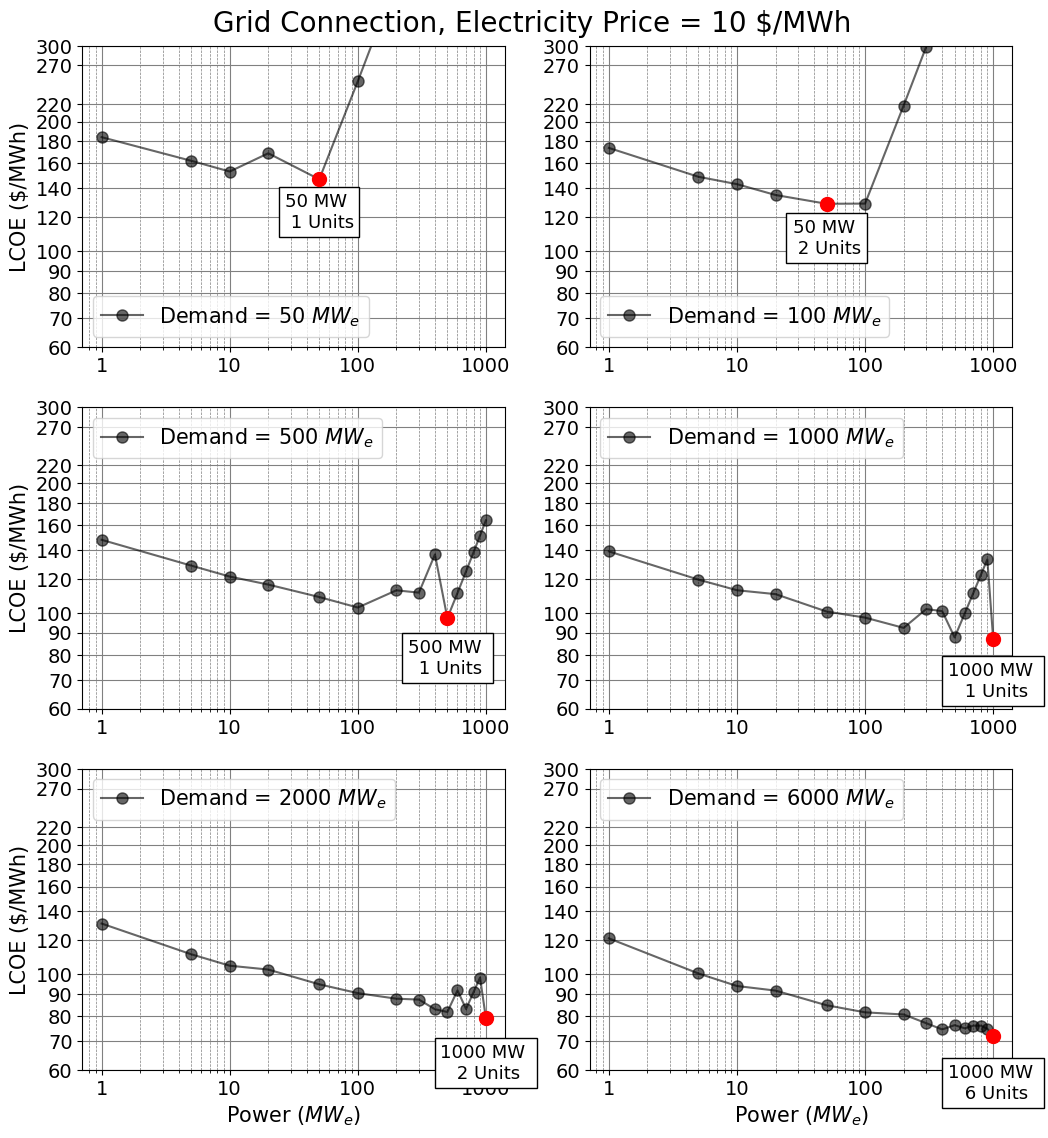

In [39]:
fig = plt.figure(figsize=(12, 18))



selected_LCOE = 'lcoe_1'
fig.suptitle(f"Grid Connection, Electricity Price = {elec_price_1} $/MWh", y = 0.9, fontsize= 20)


for ii in range (len(dem_list)):
    dem = dem_list[ii]   
    
    plt.subplot(4, 2, ii+1)
    # plt.title(f'Demand = {dem} $MW_e$', fontsize=15)
    dem_data = df_LCOE.loc[df_LCOE['demand'] == dem]
    
    
    plt.plot(dem_data ['power'], dem_data [selected_LCOE], '-o' , markersize = 8,  alpha=0.6, color = 'black', label = f'Demand = {dem} $MW_e$')
    plt.xscale('log')
    plt.yscale('log')

    
    # Find the index of the minimum value in dem_data[selected_LCOE]
    min_index = dem_data[selected_LCOE].idxmin()
    # Get the corresponding x and y values
    min_x = dem_data['power'][min_index]
    min_y = dem_data[selected_LCOE][min_index]

    
    
    # Plot the highlighted point in a different color
    plt.scatter(min_x, min_y, color='red', s=100, zorder=5)  # s is the size of the marker, zorder ensures it is plotted on top
    # number of units
    min_num_unit = dem_data['# units'][min_index]
    # Add a label at the minimum value
    
    plt.text(min_x, min_y - 10, f'{int(min_x)} MW \n {min_num_unit} Units', fontsize=13,\
        ha='center', va='top', bbox=dict(facecolor='white', edgecolor='black'))
    # plt.yscale('log')
    
    print(min_x, min_num_unit, np.round(min_y, 1) )
    if dem >= 500:
        plt.legend( loc='upper left', fontsize=15 , ncol=2)
    else:
        plt.legend( loc='lower left', fontsize=15 , ncol=2)
    
    plt.grid(which='major', color='grey', linewidth=0.8)

    plt.gca().yaxis.set_major_formatter(mpl.ticker.NullFormatter()) 
    plt.gca().yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    plt.gca().yaxis.set_minor_formatter(mpl.ticker.ScalarFormatter())

    plt.gca().xaxis.set_major_formatter(mpl.ticker.NullFormatter()) 
    plt.gca().xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    
    plt.gca().yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    plt.gca().xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(mpl.ticker.ScalarFormatter())
    
    # plt.yticks([65, 70, 75, 80, 90, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
    
    plt.yticks([60, 70, 80, 90, 100, 120, 140, 160, 180, 200,  220,  270, 300])

    
    plt.grid(which='minor', color='grey', linestyle='dashed', linewidth=0.5)
    plt.minorticks_on()
    
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    # # plt.ylim( 3, 80)
    
    plt.ylim( 0, 300)
        
    if dem == 2000 or dem == 6000:
            plt.xlabel('Power ($MW_e$)', fontsize=15)
    if dem == 50 or dem == 500 or dem == 2000:     
        plt.ylabel('LCOE ($/MWh)', fontsize=15)

             
# plt.savefig('LCOE0.png')
plt.show()

50 1 146.9
50 2 128.9
500 1 97.3
1000 1 87.0
1000 2 79.1
1000 6 72.1


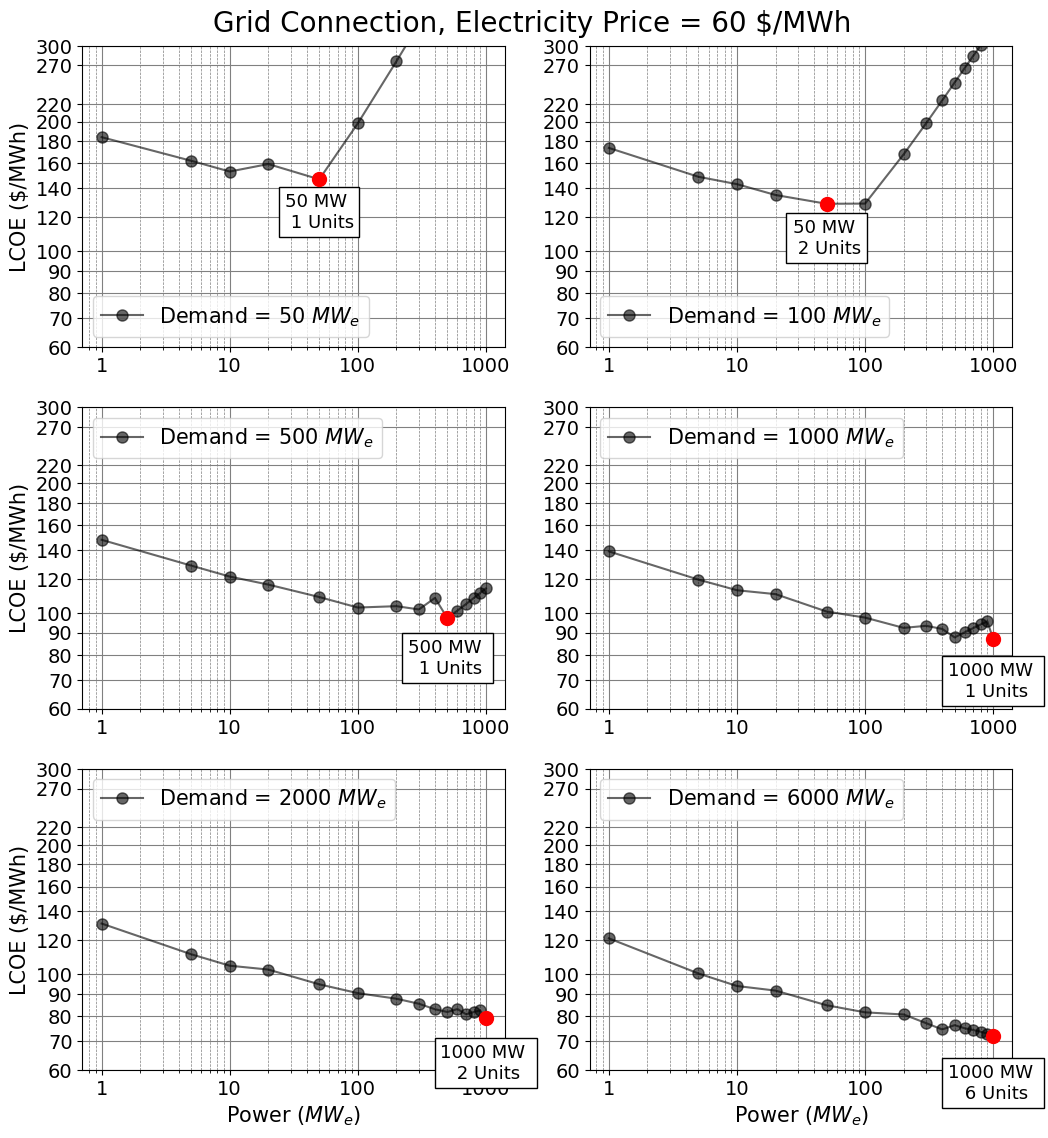

In [ ]:
fig = plt.figure(figsize=(12, 18))

# Select the electricty price to show:


selected_LCOE = 'lcoe_3'
fig.suptitle(f"Grid Connection, Electricity Price = {elec_price_3} $/MWh", y = 0.9, fontsize= 20)

# elif price ==1:  
#     selected_LCOE = 'lcoe_1'
#     fig.suptitle(f"Surplus Energy is sold to the grid. Electricity price is {elec_price_1} $/MWh", y = 0.9, fontsize=20)
# elif price ==2:  
#     selected_LCOE = 'lcoe_2'
#     fig.suptitle(f"Surplus Energy is sold to the grid. Electricity price is {elec_price_2}$/ MWh", y = 0.9, fontsize=20)
# elif price ==3:
#     selected_LCOE = 'lcoe_3'
#     fig.suptitle(f"Surplus Energy is sold to the grid. Electricity price is {elec_price_3} $/MWh", y = 0.9, fontsize=20)




for ii in range (len(dem_list)):
    dem = dem_list[ii]
    # fig = plt.figure(figsize=(8, 5))
    # plt.title( f"Demand  = {dem} $MW_e$ ",  fontsize=18)
    
    
    plt.subplot(4, 2, ii+1)
    # plt.title(f'Demand = {dem} $MW_e$', fontsize=15)
    dem_data = df_LCOE.loc[df_LCOE['demand'] == dem]
    
    
    # CF_data = dem_data.loc[dem_data['capacity factor criteria'] == cap_fact]
    plt.plot(dem_data ['power'], dem_data [selected_LCOE], '-o' , markersize = 8,  alpha=0.6, color = 'black', label = f'Demand = {dem} $MW_e$')
    plt.xscale('log')
    plt.yscale('log')

    
    # Find the index of the minimum value in dem_data[selected_LCOE]
    min_index = dem_data[selected_LCOE].idxmin()
    # Get the corresponding x and y values
    min_x = dem_data['power'][min_index]
    min_y = dem_data[selected_LCOE][min_index]

    
    
    # Plot the highlighted point in a different color
    plt.scatter(min_x, min_y, color='red', s=100, zorder=5)  # s is the size of the marker, zorder ensures it is plotted on top
    # number of units
    min_num_unit = dem_data['# units'][min_index]
    # Add a label at the minimum value
    
    plt.text(min_x, min_y - 10, f'{int(min_x)} MW \n {min_num_unit} Units', fontsize=13,\
        ha='center', va='top', bbox=dict(facecolor='white', edgecolor='black'))
    # plt.yscale('log')
    
    print(min_x, min_num_unit, np.round(min_y, 1) )
    if dem >= 500:
        plt.legend( loc='upper left', fontsize=15 , ncol=2)
    else:
        plt.legend( loc='lower left', fontsize=15 , ncol=2)
    
    plt.grid(which='major', color='grey', linewidth=0.8)

    plt.gca().yaxis.set_major_formatter(mpl.ticker.NullFormatter()) 
    plt.gca().yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    plt.gca().yaxis.set_minor_formatter(mpl.ticker.ScalarFormatter())

    plt.gca().xaxis.set_major_formatter(mpl.ticker.NullFormatter()) 
    plt.gca().xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    
    plt.gca().yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    plt.gca().xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    plt.gca().yaxis.set_minor_formatter(mpl.ticker.ScalarFormatter())
    
    # plt.yticks([65, 70, 75, 80, 90, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300])
    
    plt.yticks([60, 70, 80, 90, 100, 120, 140, 160, 180, 200,  220,  270, 300])

    
    plt.grid(which='minor', color='grey', linestyle='dashed', linewidth=0.5)
    plt.minorticks_on()
    
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    # # plt.ylim( 3, 80)
    
    plt.ylim( 0, 300)
        
    if dem == 2000 or dem == 6000:
            plt.xlabel('Power ($MW_e$)', fontsize=15)
    if dem == 50 or dem == 500 or dem == 2000:     
        plt.ylabel('LCOE ($/MWh)', fontsize=15)

             
# plt.savefig('LCOE0.png')
plt.show()

In [10]:
# just an experiment!


dem_list = [ 100,  1000, 6000]


LCOE_results = []

power_list = [1000, 900 , 800, 700, 600, 500, 400, 300, 200, 100  ,50, 20, 10]
interest_rate = 0.06
levelization_period_0 = int(365 * 40/7) # 40 years


for tot_demand in  dem_list:
    print(f'Demand is {tot_demand}')
    for reactor_power in power_list:
        num_reactors_needed = int(np.ceil(num_reactors_needed_for_capacity_factor_weeks_apprioach(0, 0.9 ,\
            0 , reactor_power, levelization_period_0, tot_demand)))
        print(reactor_power, num_reactors_needed)
        schedule_results = capacity_factor_weeks_approach( num_reactors_needed, reactor_power, levelization_period_0, tot_demand)
        
        Tot_MWh_generated_per_year_list = schedule_results[3]
        MWh_generated_per_year_per_demand_list = schedule_results[4]
        MWh_excess_per_year_list = schedule_results[5]
        lcoe_1 = level_cost_of_energy_starting_from_BOAK( interest_rate, reactor_power, num_reactors_needed, Tot_MWh_generated_per_year_list,MWh_generated_per_year_per_demand_list, MWh_excess_per_year_list, 0)


        LCOE_results.append({'demand': tot_demand, 'capacity factor criteria' :0.9  ,\
            'power':reactor_power, '# units' : num_reactors_needed  ,'lcoe_1':lcoe_1})
               
df_LCOE_exp= pd.DataFrame(LCOE_results)
         

Demand is 100
1000 2
900 2
800 2
700 2
600 2
500 2
400 2
300 2
200 2
100 2
50 3
20 6
10 10
Demand is 1000
1000 2
900 2
800 3
700 3
600 3
500 3
400 4
300 4
200 6
100 10
50 19
20 48
10 95
Demand is 6000
1000 7
900 7
800 8
700 9
600 10
500 12
400 15
300 19
200 29
100 57
50 112
20 284
10 562
